<a href="https://colab.research.google.com/github/vijaydevverse/ML-DL-Projects-Portfolio/blob/main/Cervical_Cancer_Prediction_Using_Machine_Learning_and_Deep_Learning_Project_6_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

With Biopsy as the prediction variable, the task involves using other features in the dataset to predict whether a patient is likely to have cervical cancer. This can be approached as a binary classification problem, where the model learns patterns from demographic, reproductive, lifestyle, and medical history attributes to predict the likelihood of a positive biopsy result (0 = Negative, 1 = Positive).

Cervical cancer is one of the most common cancers affecting women worldwide and remains a significant public health concern. Early detection plays a crucial role in improving treatment outcomes and reducing mortality rates. In this project, a predictive model is developed using patient-related factors such as age, sexual behavior, smoking habits, contraceptive usage, sexually transmitted diseases (STDs), and diagnostic information. The objective is to predict the Biopsy outcome and assist healthcare professionals in identifying high-risk individuals, enabling timely screening, diagnosis, and preventive care.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv('/content/cervical_cancer_100k_rows.csv')
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,41,3.0,20.0,NaN,0.0,0.0,0.0,1.0,8.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
99996,59,2.0,13.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,0,1,0,1,0,0,0,0
99997,21,1.0,17.0,NaN,0.0,0.0,0.0,1.0,3.0,0.0,...,NaN,NaN,0,1,0,1,0,0,0,1
99998,45,2.0,17.0,NaN,0.0,0.0,0.0,1.0,6.0,1.0,...,NaN,NaN,0,1,0,1,0,0,0,0


In [ ]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
df.tail()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
99995,41,3.0,20.0,NaN,0.0,0.0,0.0,1.0,8.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
99996,59,2.0,13.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,0,1,0,1,0,0,0,0
99997,21,1.0,17.0,NaN,0.0,0.0,0.0,1.0,3.0,0.0,...,NaN,NaN,0,1,0,1,0,0,0,1
99998,45,2.0,17.0,NaN,0.0,0.0,0.0,1.0,6.0,1.0,...,NaN,NaN,0,1,0,1,0,0,0,0
99999,21,3.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,1,0,1,0,0,0,1


In [ ]:
df.shape

(100000, 36)

In [ ]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Age                                 100000 non-null  int64  
 1   Number of sexual partners           97003 non-null   float64
 2   First sexual intercourse            99163 non-null   float64
 3   Num of pregnancies                  93316 non-null   float64
 4   Smokes                              98444 non-null   float64
 5   Smokes (years)                      98444 non-null   float64
 6   Smokes (packs/year)                 98444 non-null   float64
 7   Hormonal Contraceptives             87659 non-null   float64
 8   Hormonal Contraceptives (years)     87659 non-null   float64
 9   IUD                                 86582 non-null   float64
 10  IUD (years)                         86582 non-null   float64
 11  STDs                       

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,2997
First sexual intercourse,837
Num of pregnancies,6684
Smokes,1556
Smokes (years),1556
Smokes (packs/year),1556
Hormonal Contraceptives,12341
Hormonal Contraceptives (years),12341
IUD,13418


In [ ]:
df.duplicated().sum()

np.int64(99165)

In [ ]:
target='Biopsy'

In [ ]:
df[target].value_counts()

,count
Biopsy,
0,93535
1,6465


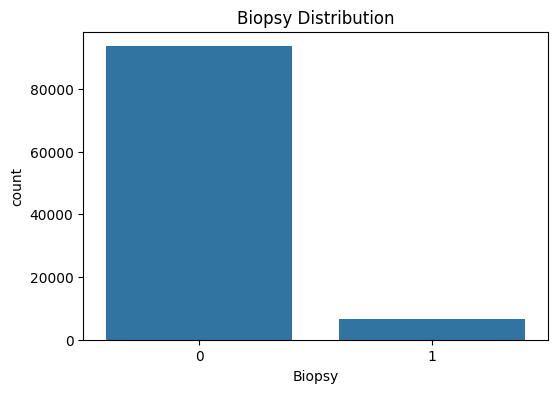

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=target,data=df)

plt.title("Biopsy Distribution")

plt.show()

In [ ]:
df=df.fillna(df.median(numeric_only=True))

df.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [ ]:
categorical_cols=df.select_dtypes(include='object').columns

categorical_cols

numeric_cols=df.select_dtypes(include=['int64','float64']).columns

numeric_cols

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

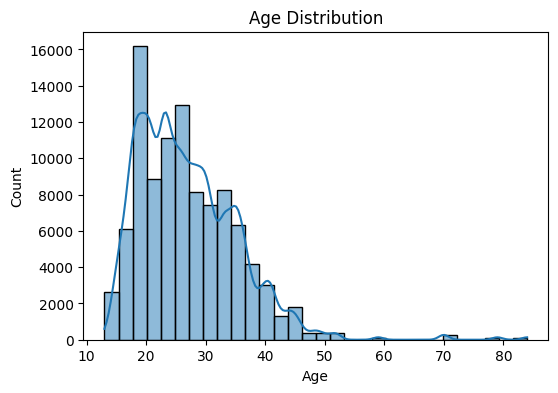

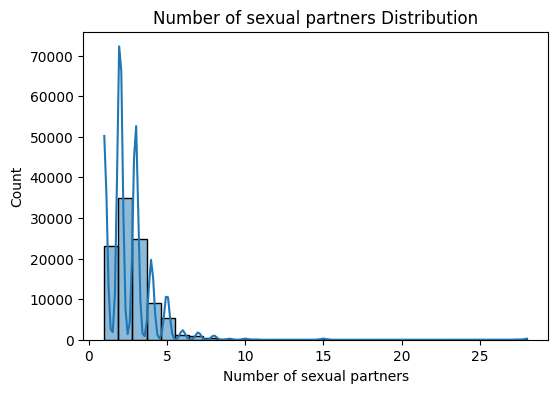

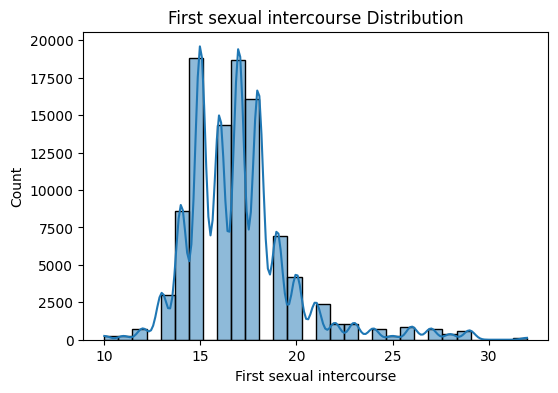

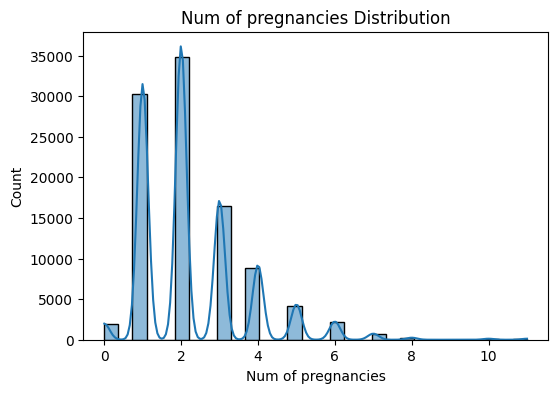

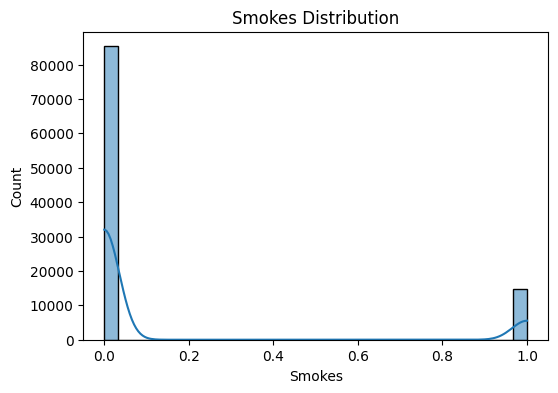

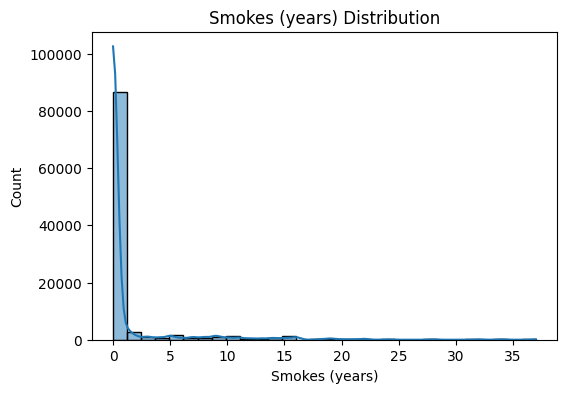

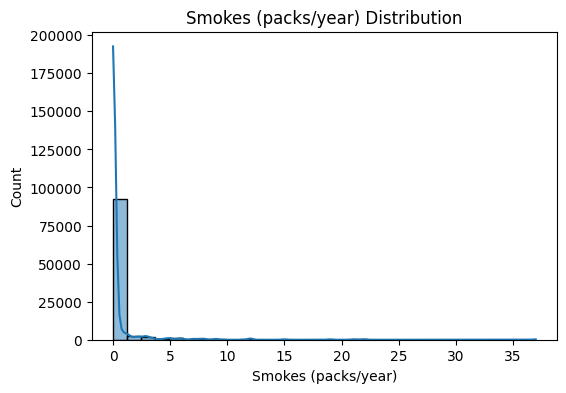

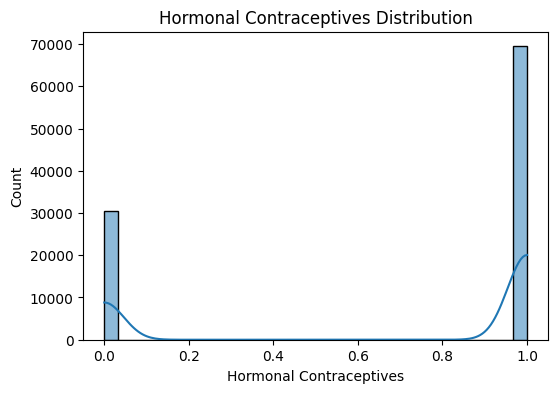

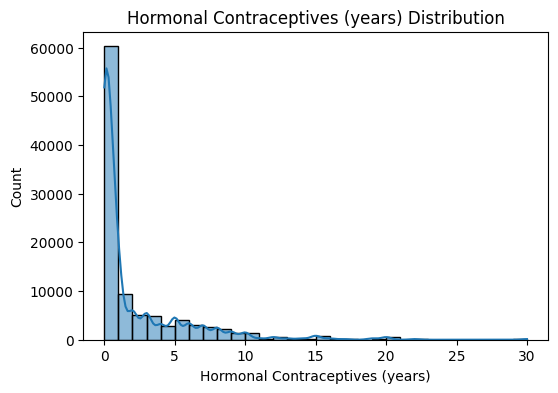

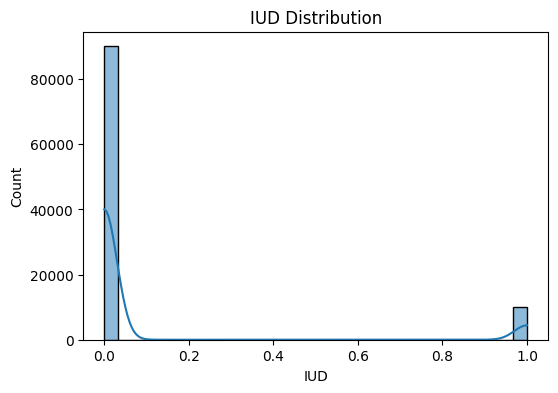

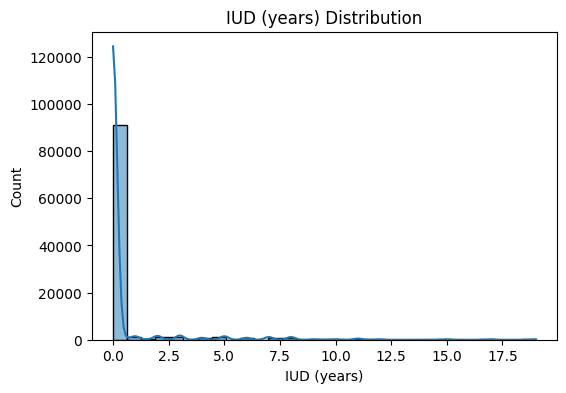

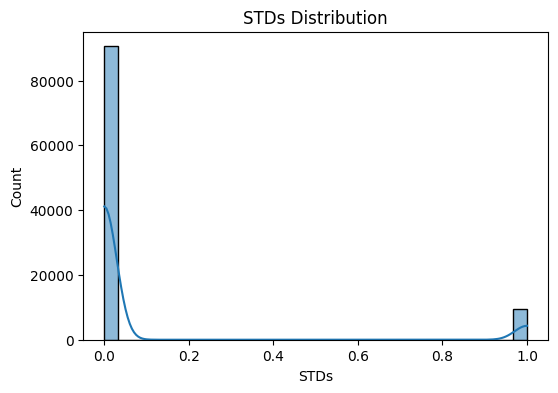

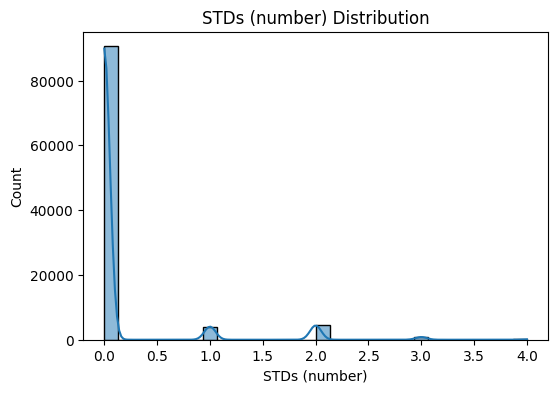

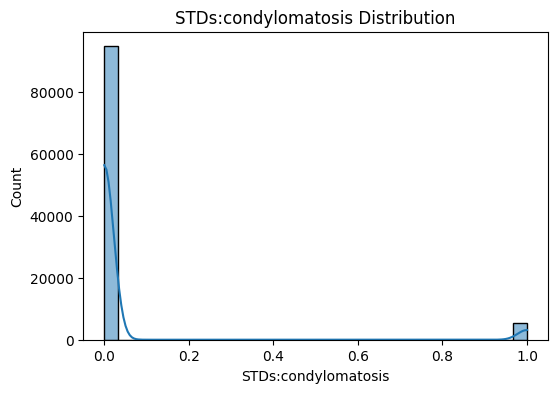

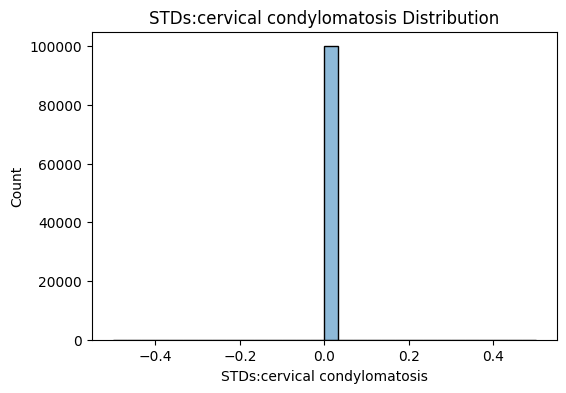

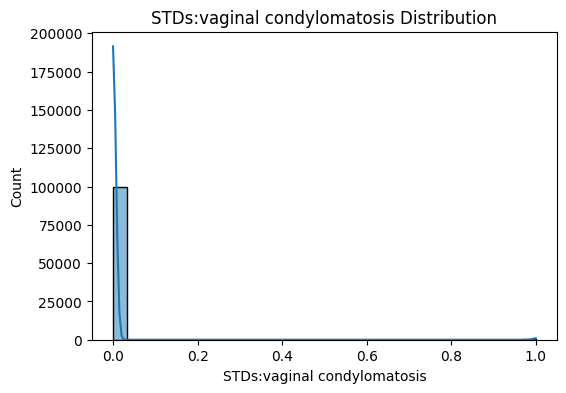

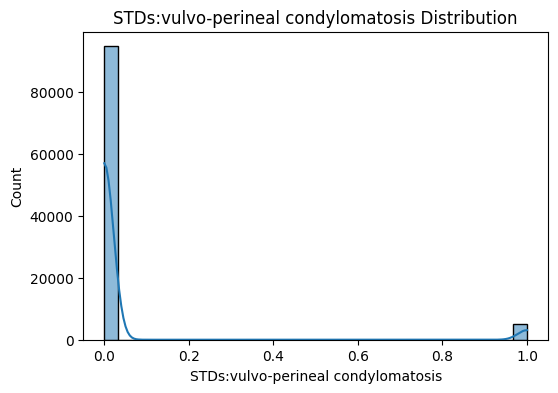

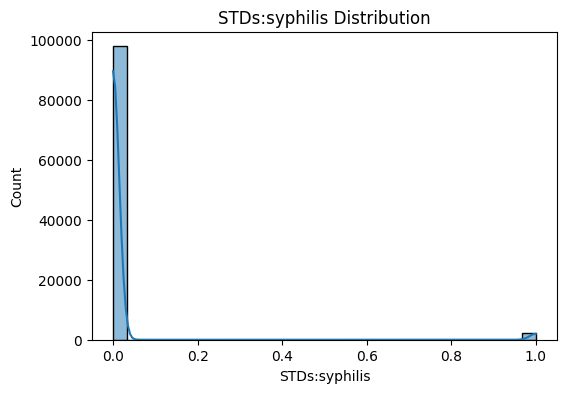

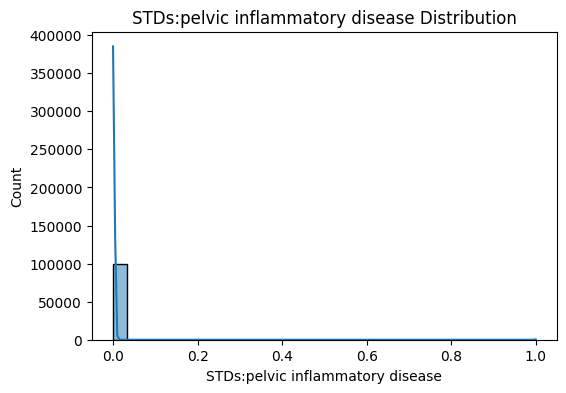

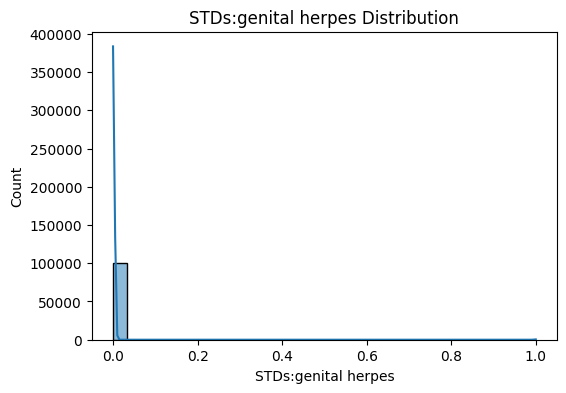

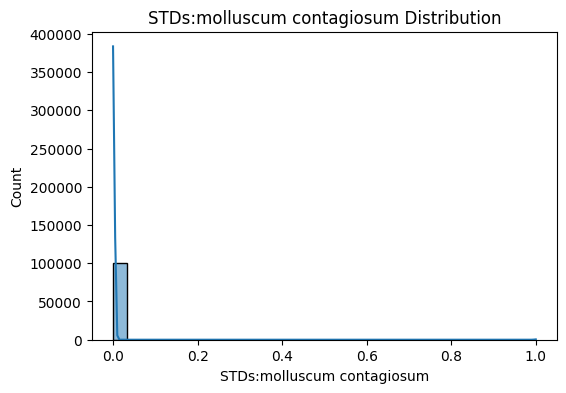

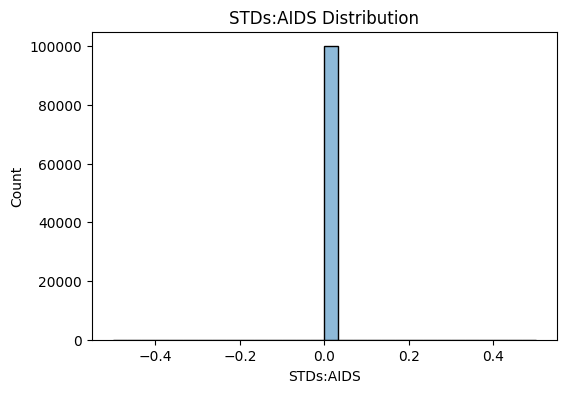

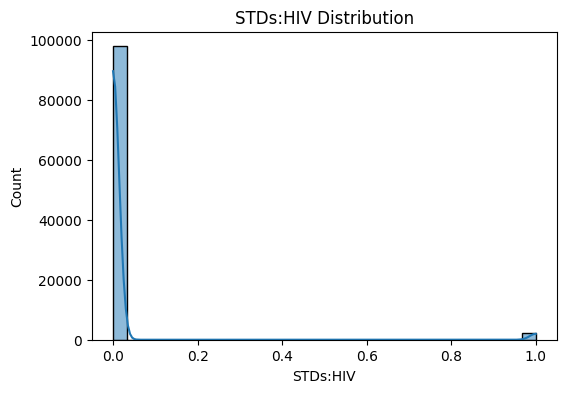

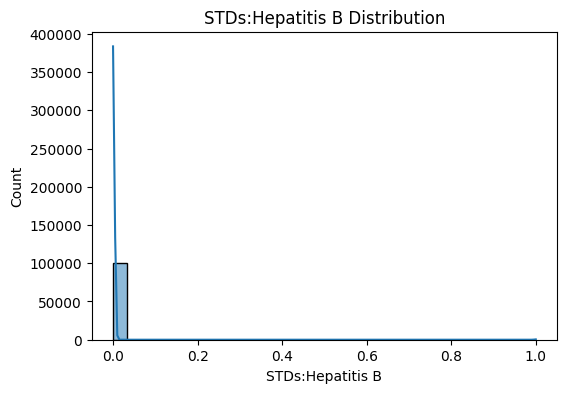

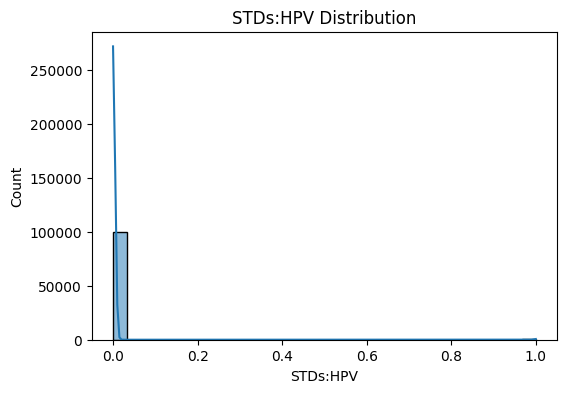

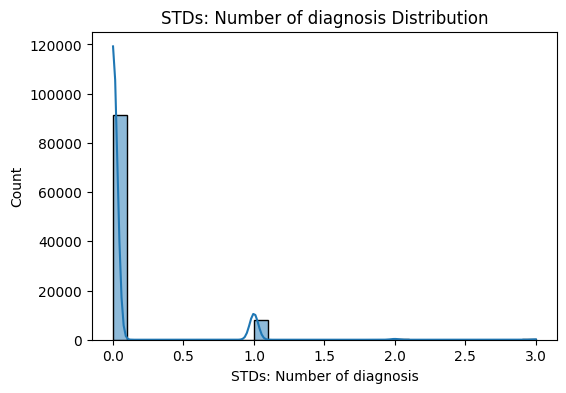

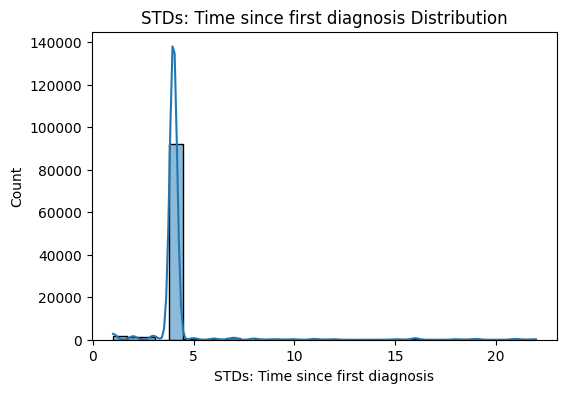

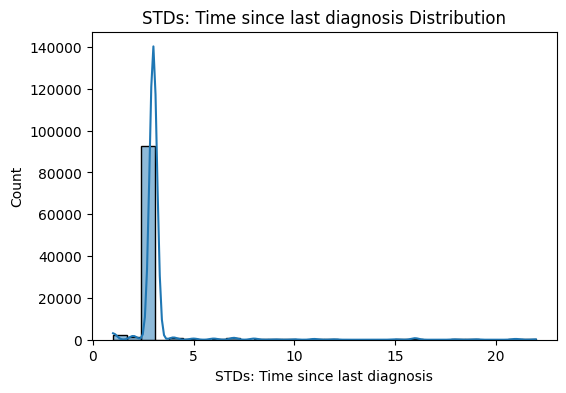

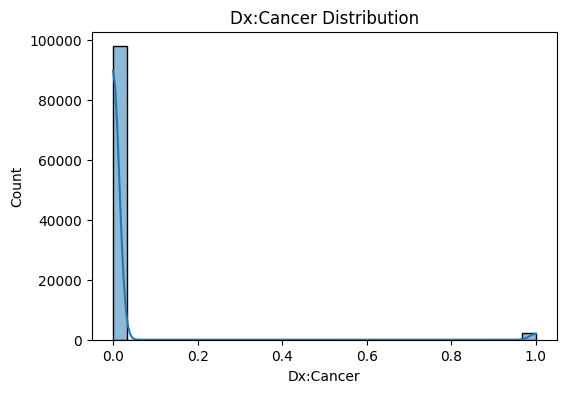

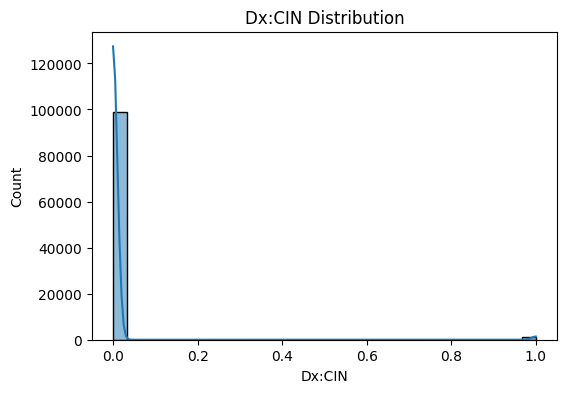

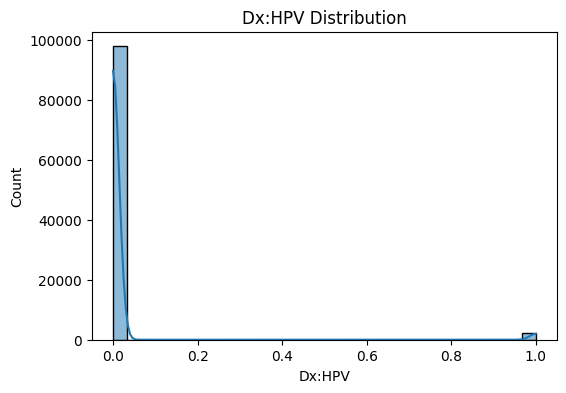

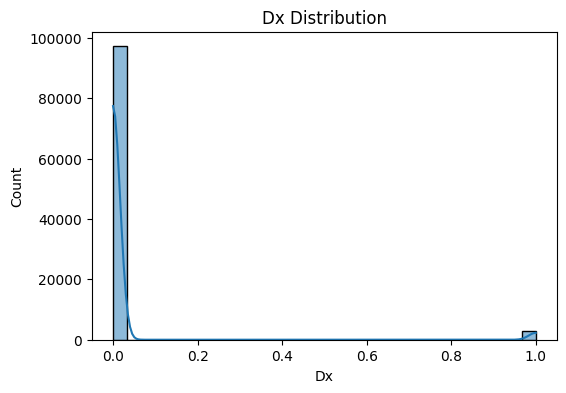

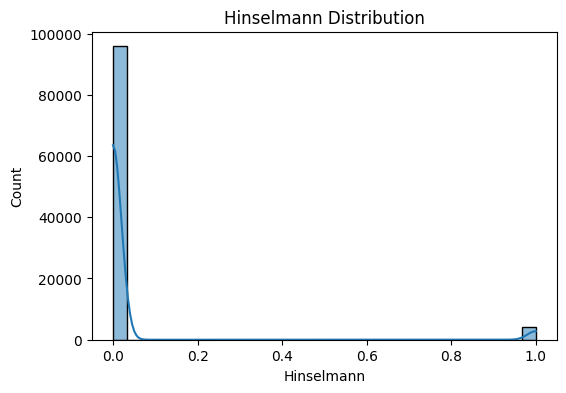

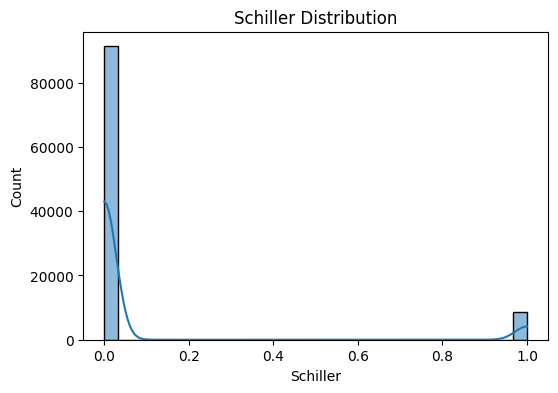

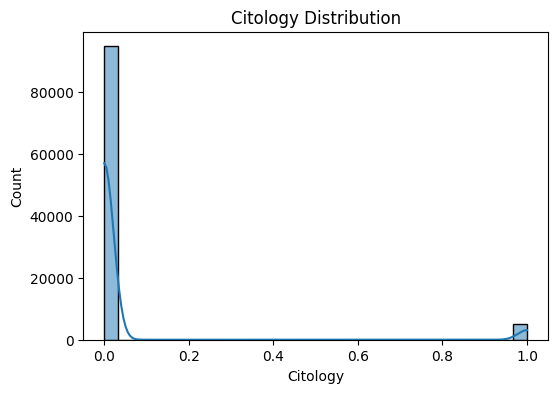

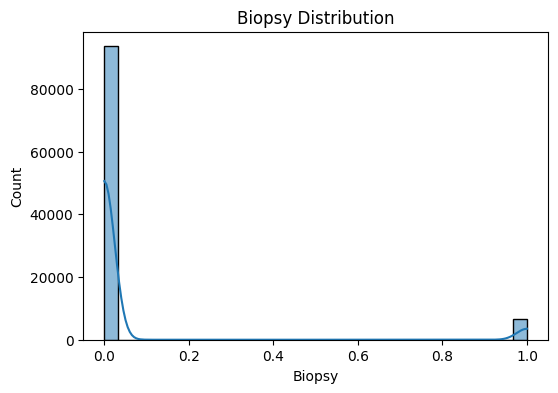

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],bins=30,kde=True)

    plt.title(f'{col} Distribution')

    plt.show()

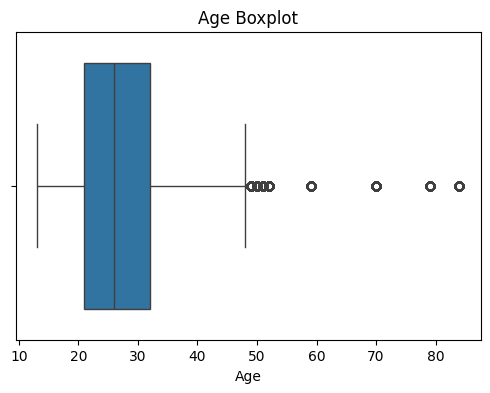

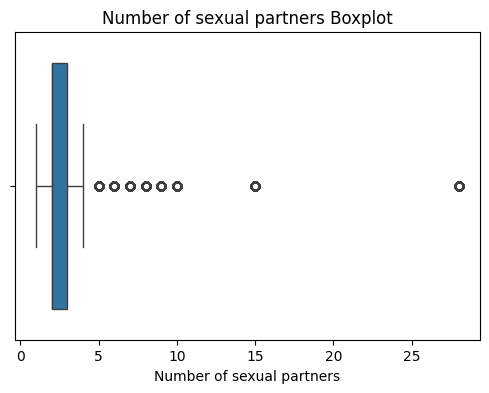

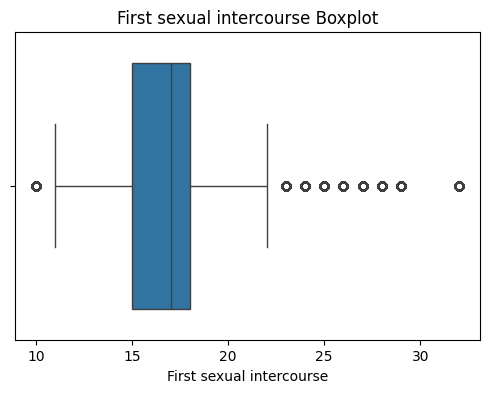

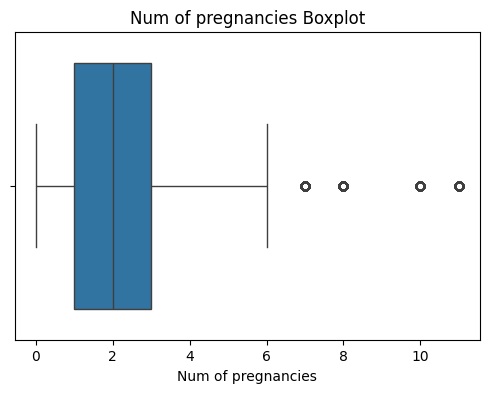

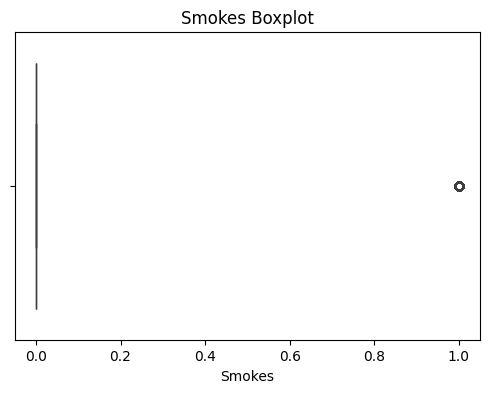

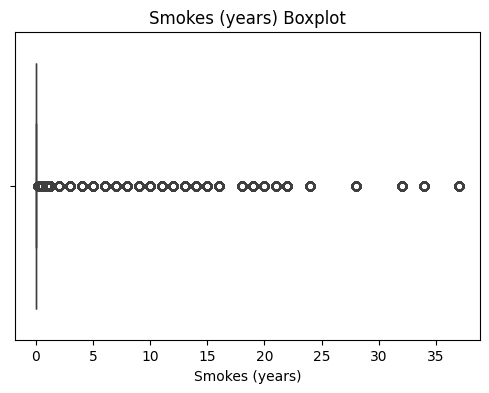

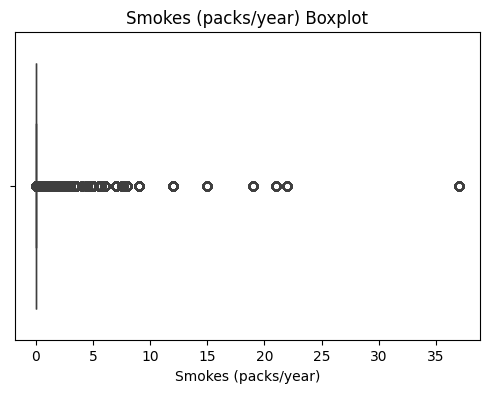

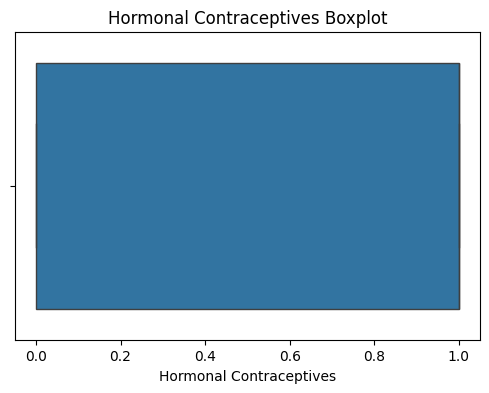

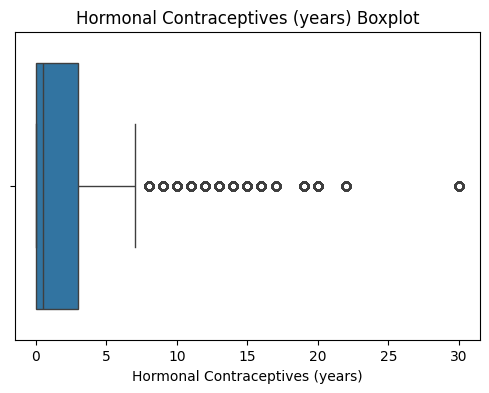

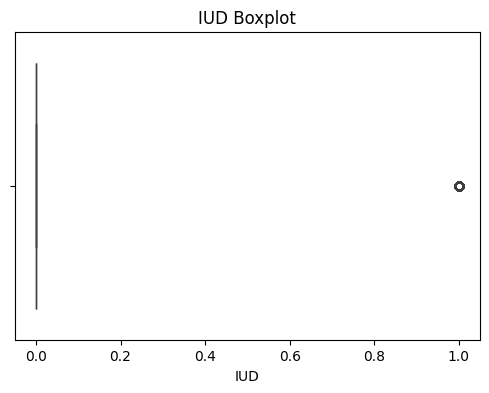

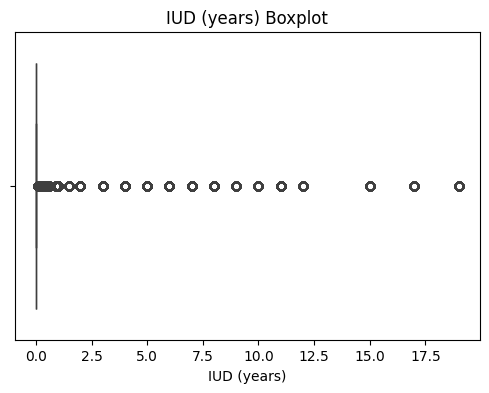

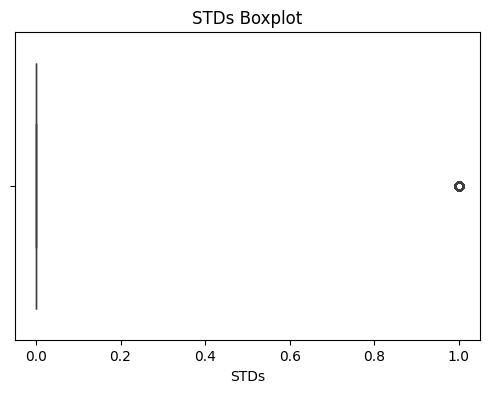

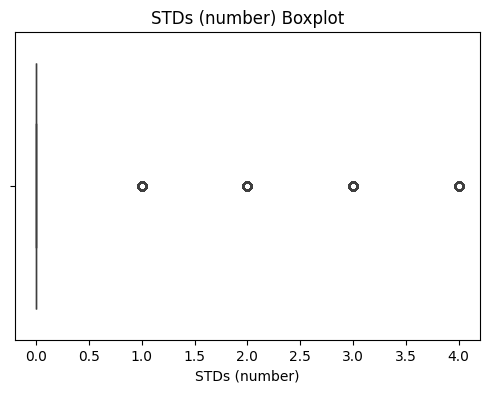

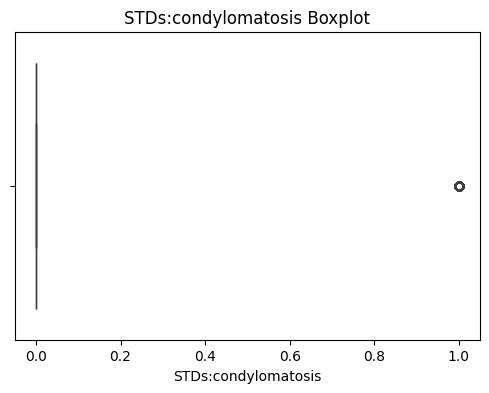

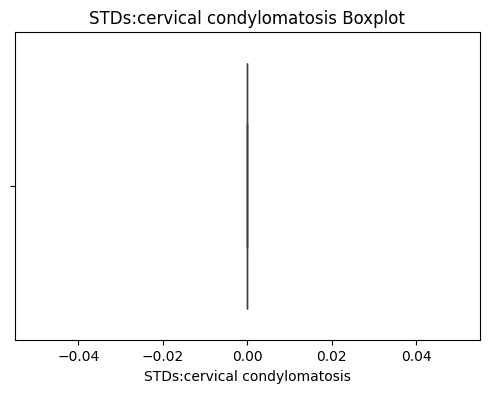

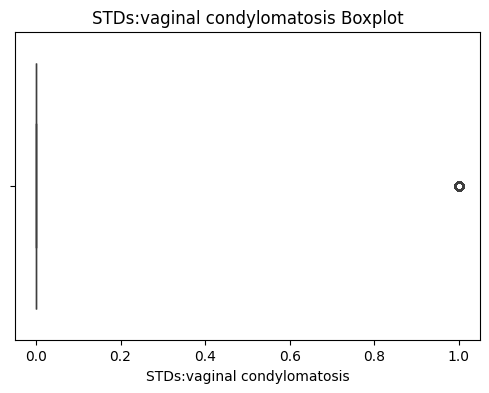

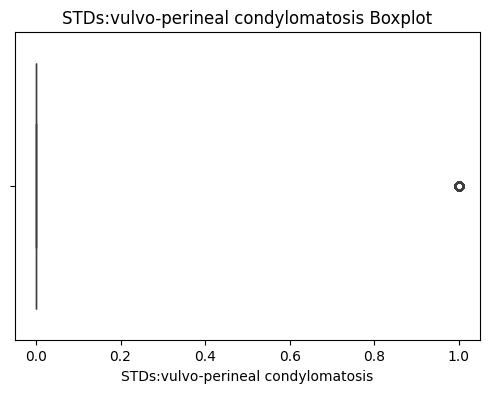

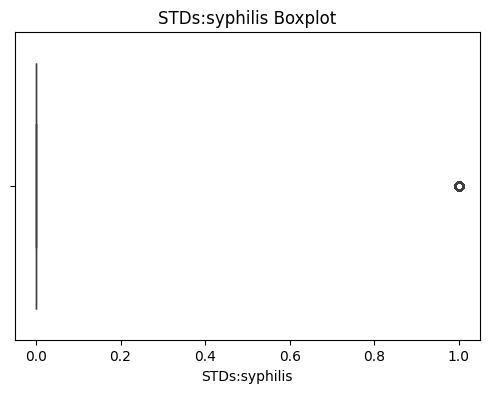

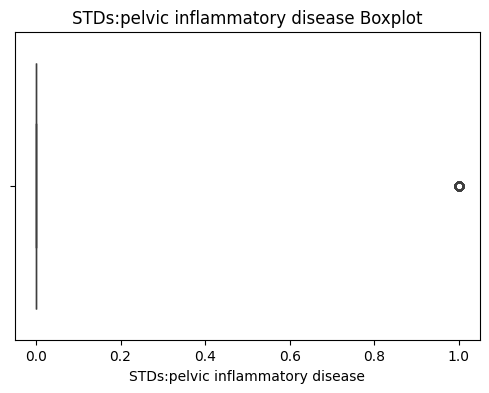

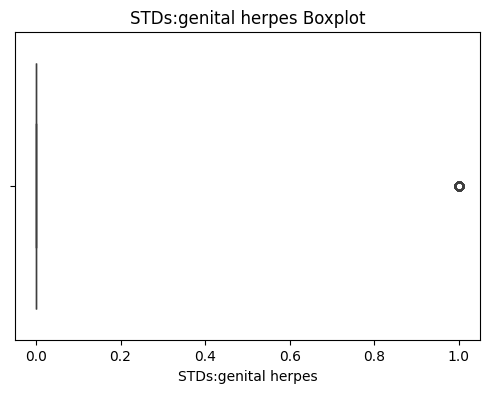

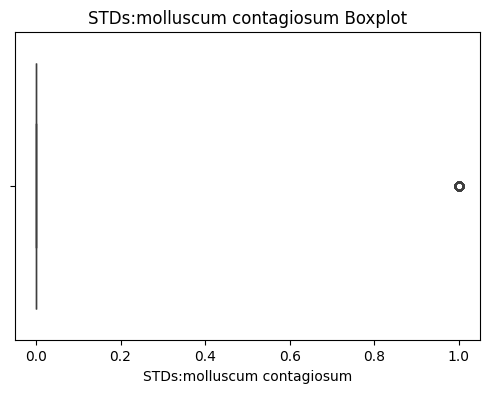

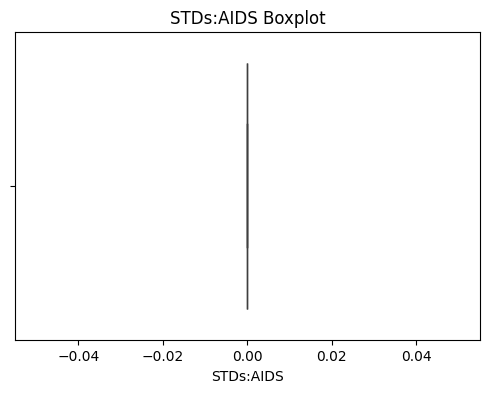

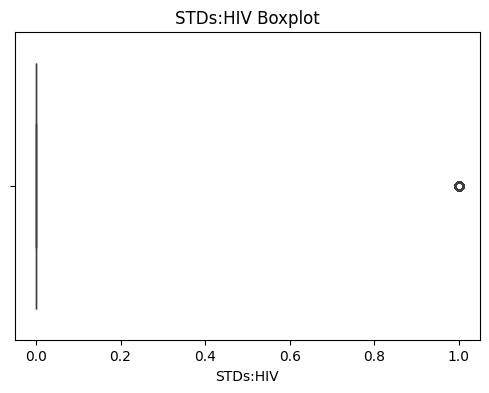

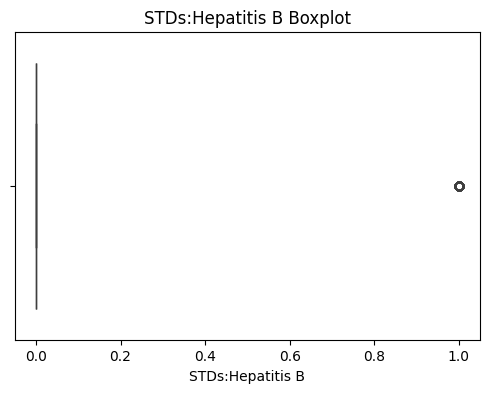

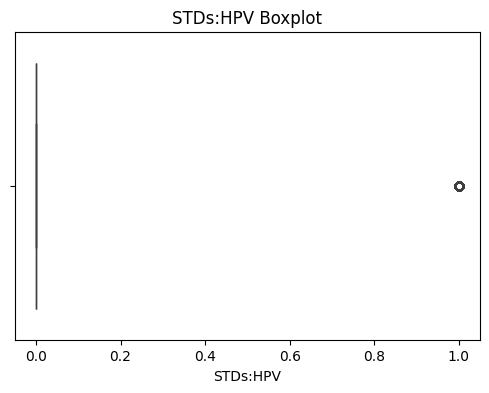

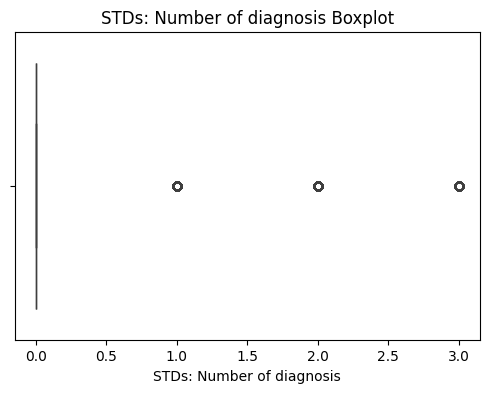

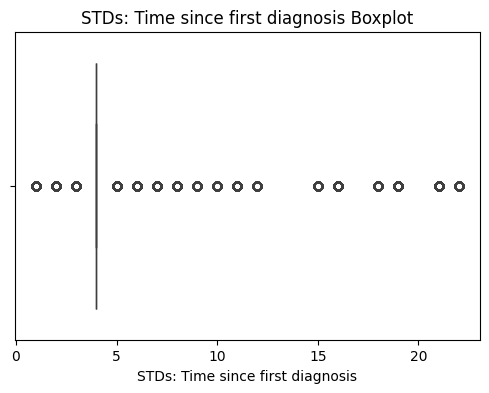

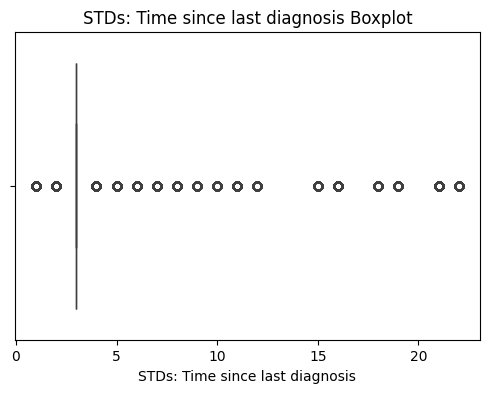

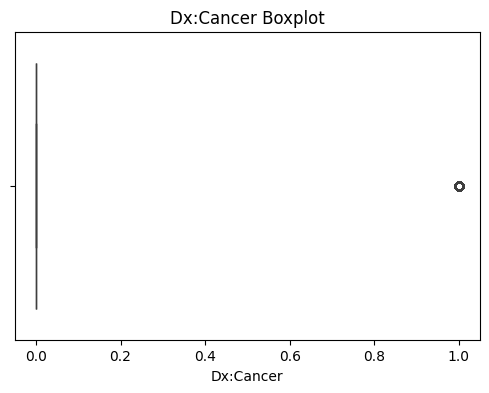

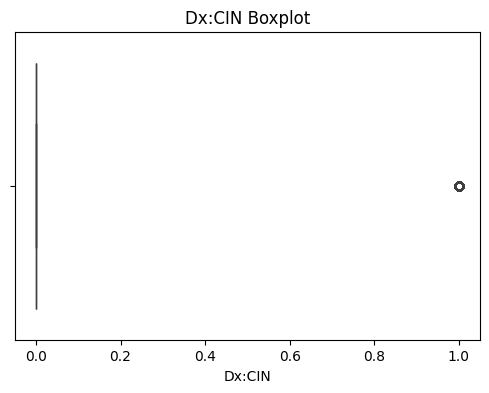

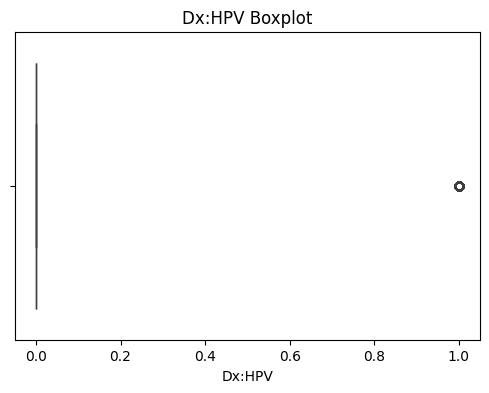

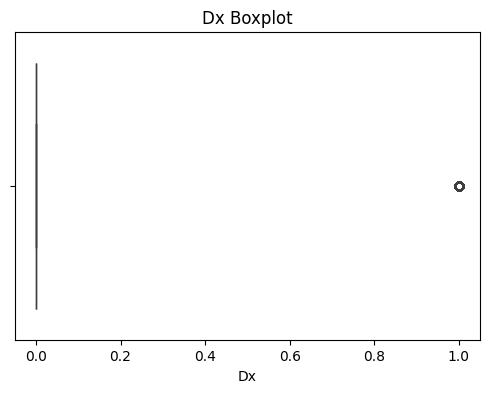

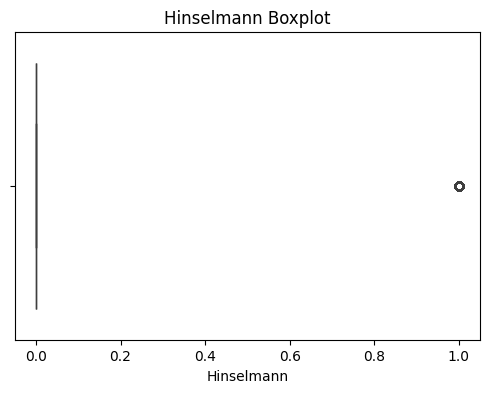

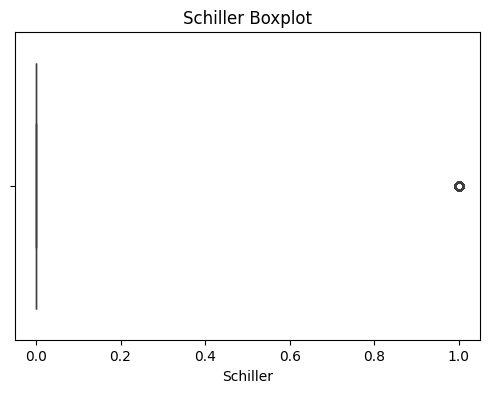

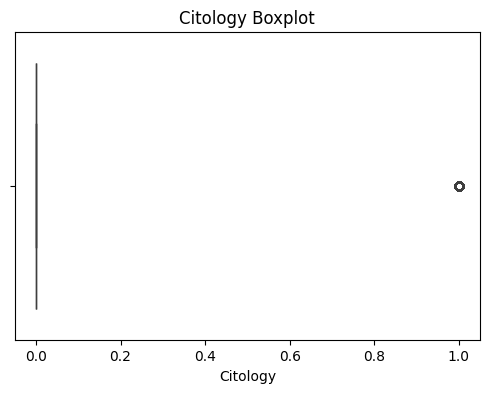

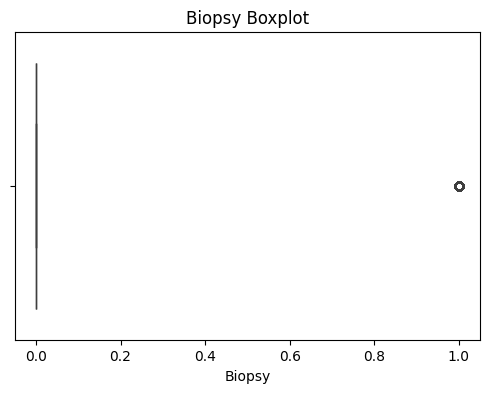

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'{col} Boxplot')

    plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

x=df.drop('Biopsy',axis=1)

y=df['Biopsy']

smote=SMOTE(random_state=42)

x_resampled,y_resampled=smote.fit_resample(x,y)

df_resampled=pd.concat(
    [pd.DataFrame(x_resampled,columns=x.columns),
     pd.DataFrame(y_resampled,columns=['Biopsy'])],
    axis=1
)

df=df_resampled

print(df['Biopsy'].value_counts())

Biopsy
0    93535
1    93535
Name: count, dtype: int64


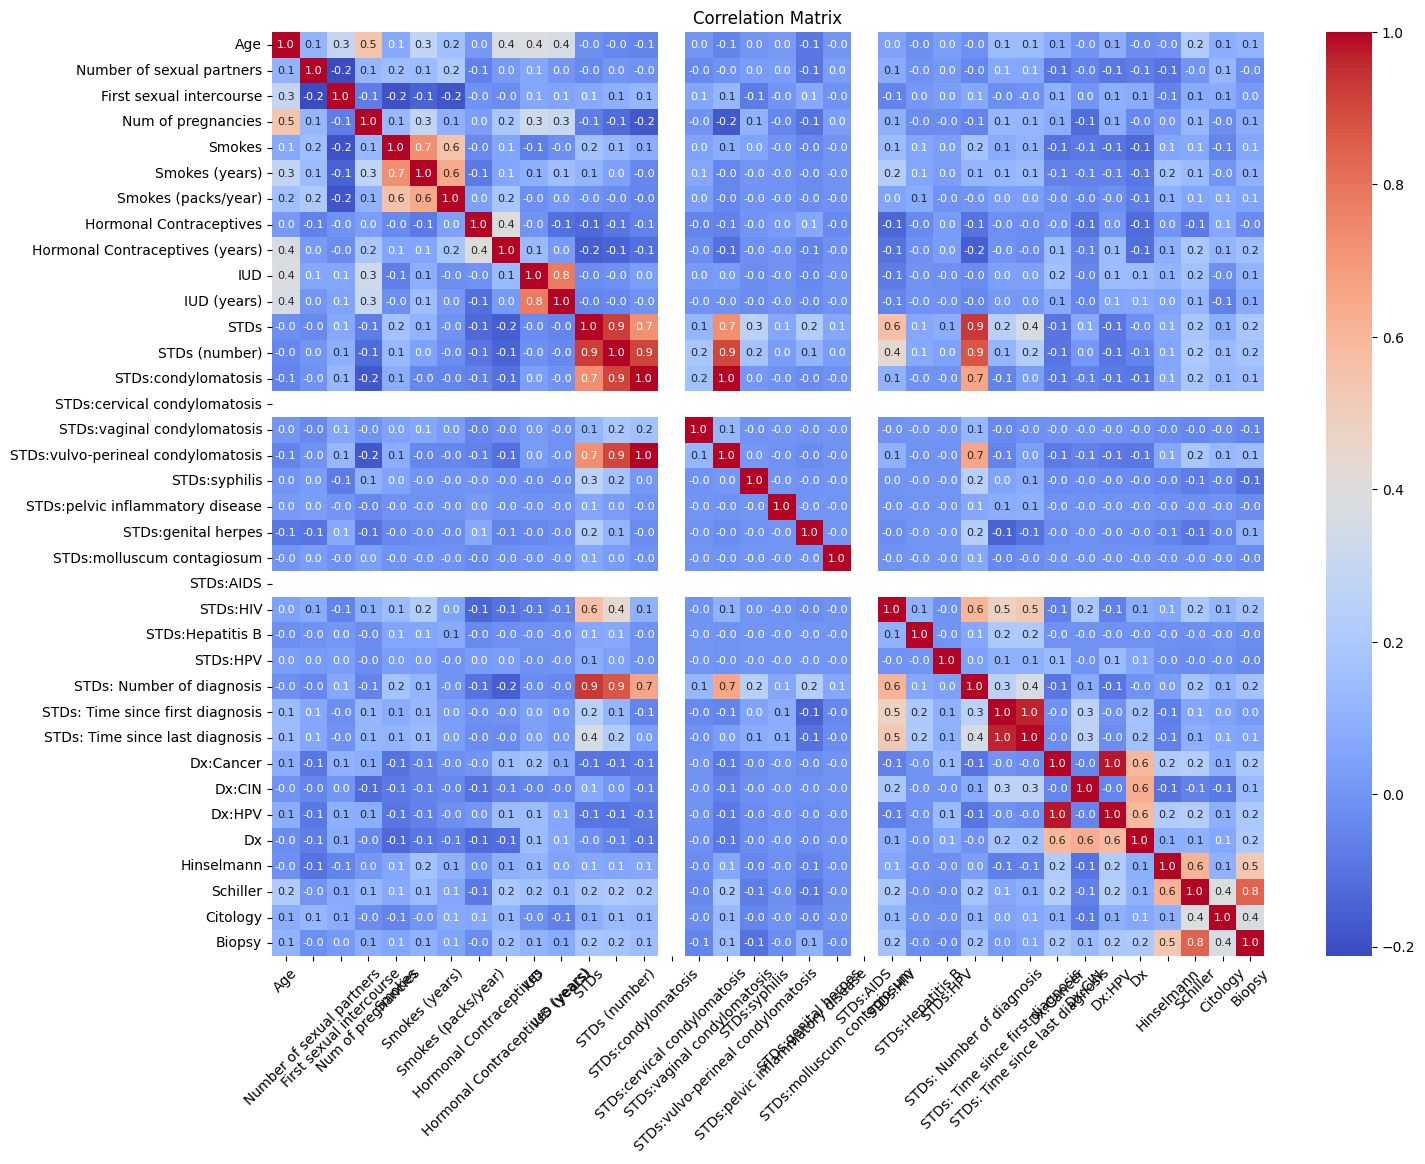

In [ ]:
plt.figure(figsize=(16,12))

cm=df.corr(numeric_only=True)

sns.heatmap(cm,
            annot=True,
            fmt=".1f",
            cmap="coolwarm",
            annot_kws={"size":8})

plt.title("Correlation Matrix")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

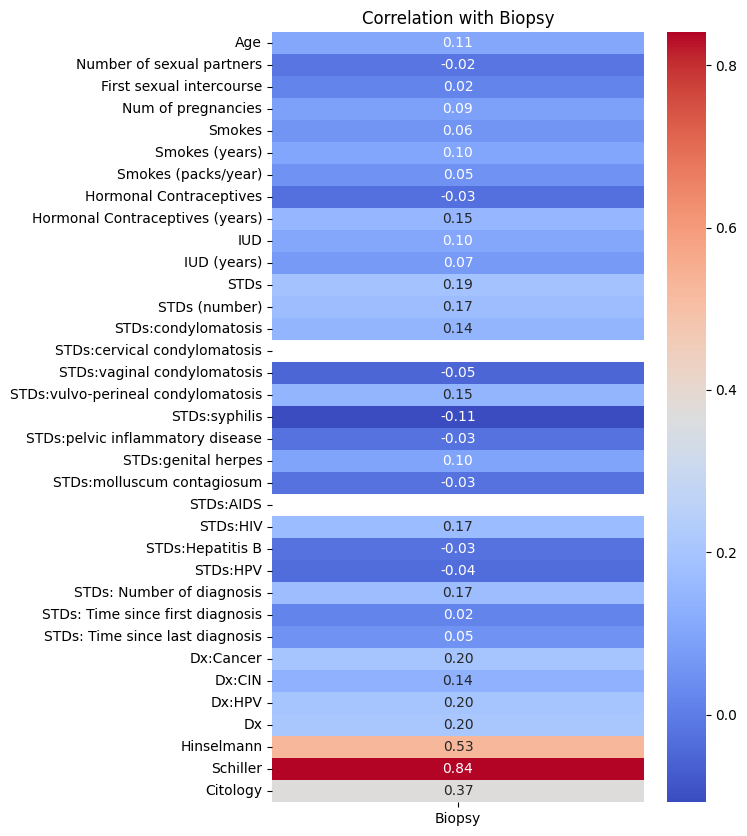

In [ ]:
corr=df.corr(numeric_only=True)['Biopsy']

corr=corr.drop('Biopsy')

plt.figure(figsize=(6,10))

sns.heatmap(corr.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True)

plt.title('Correlation with Biopsy')

plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=['int64','float64']).columns:

        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df

df=remove_outliers_iqr(df,exclude_column='Biopsy')

df.shape

(53708, 36)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features=df.drop('Biopsy',axis=1).columns

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

scaled_df['Biopsy']=df['Biopsy'].values

In [ ]:
from sklearn.model_selection import train_test_split

X=scaled_df.drop('Biopsy',axis=1)
y=scaled_df['Biopsy']

x_train,x_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.25,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

lr_model=LogisticRegression(max_iter=1000)

lr_model.fit(x_train,y_train)

y_pred_lr=lr_model.predict(x_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 1.0


In [ ]:
print("\nClassification Report")
print(classification_report(y_test,y_pred_lr))


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13001
           1       1.00      1.00      1.00       426

    accuracy                           1.00     13427
   macro avg       1.00      1.00      1.00     13427
weighted avg       1.00      1.00      1.00     13427



In [ ]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred_lr))


Confusion Matrix
[[13001     0]
 [    0   426]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 1.0


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model=GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train,y_train)

y_pred_gb=gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 1.0


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model=AdaBoostClassifier(random_state=42)

ada_model.fit(x_train,y_train)

y_pred_ada=ada_model.predict(x_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test,y_pred_ada))

AdaBoost Accuracy: 1.0


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model=AdaBoostClassifier(random_state=42)

ada_model.fit(x_train,y_train)

y_pred_ada=ada_model.predict(x_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test,y_pred_ada))

AdaBoost Accuracy: 1.0


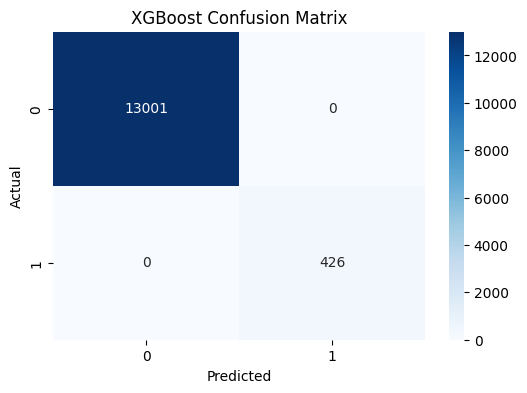

In [ ]:
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

xgb_model=XGBClassifier(eval_metric='logloss',random_state=42)
xgb_model.fit(x_train,y_train)
y_pred_xgb=xgb_model.predict(x_test)

cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model=SVC(kernel='rbf')

svm_model.fit(x_train,y_train)

y_pred_svm=svm_model.predict(x_test)

print("SVM Accuracy:",
      accuracy_score(y_test,y_pred_svm))

SVM Accuracy: 1.0


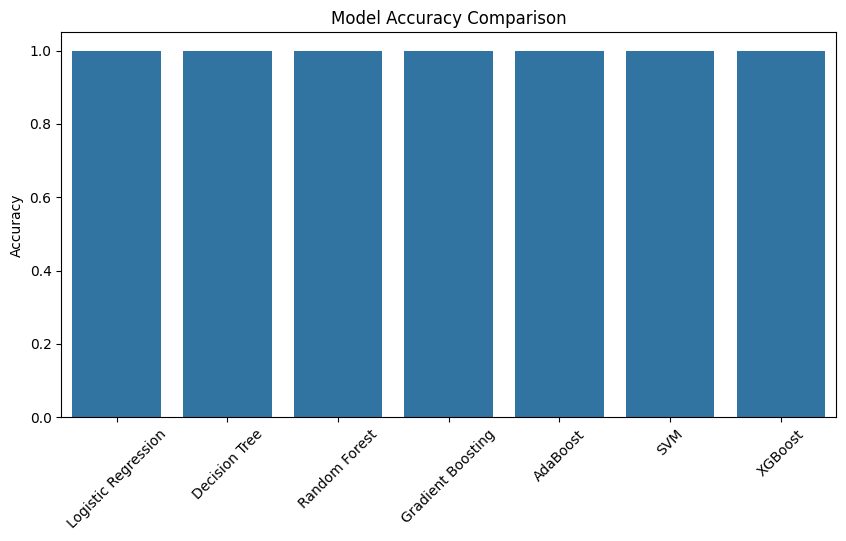

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost'
]

accuracies=[
    accuracy_score(y_test,y_pred_lr),
    accuracy_score(y_test,y_pred_dt),
    accuracy_score(y_test,y_pred_rf),
    accuracy_score(y_test,y_pred_gb),
    accuracy_score(y_test,y_pred_ada),
    accuracy_score(y_test,y_pred_svm),
    accuracy_score(y_test,y_pred_xgb)
]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X=scaled_df.drop('Biopsy',axis=1)
y=scaled_df['Biopsy']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=50000)

best_accuracy=0
best_fold=0

best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None

for fold,(train_index,test_index) in enumerate(kf.split(X),1):

    print(f"\nFold {fold}")

    X_train=X.iloc[train_index]
    X_test=X.iloc[test_index]

    y_train=y.iloc[train_index]
    y_test=y.iloc[test_index]

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=X_train
        best_y_train=y_train

        best_X_test=X_test
        best_y_test=y_test

print(f"\nBest Fold: {best_fold}")
print(f"Best Accuracy: {best_accuracy}")


Fold 1
Accuracy: 1.0

Fold 2
Accuracy: 1.0

Fold 3
Accuracy: 1.0

Fold 4
Accuracy: 1.0

Fold 5
Accuracy: 1.0

Best Fold: 1
Best Accuracy: 1.0


In [ ]:
model=LogisticRegression(max_iter=50000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 1.0


In [ ]:
model=RandomForestClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 1.0


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 1.0


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 1.0


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 1.0


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 1.0


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 1.0


**Deep Learning Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score

model=Sequential()

model.add(Dense(256,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    best_X_train,
    best_y_train,
    epochs=100,
    validation_split=0.2
)

y_pred=model.predict(best_X_test)

y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 2/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 7.6849e-06 - val_accuracy: 1.0000 - val_loss: 8.1389e-05
Epoch 3/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 1.5056e-06 - val_accuracy: 1.0000 - val_loss: 2.5590e-05
Epoch 4/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 5.5966e-07 - val_accuracy: 1.0000 - val_loss: 8.8325e-06
Epoch 5/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 2.4963e-07 - val_accuracy: 1.0000 - val_loss: 4.2121e-06
Epoch 6/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 1.2249e-07 - val_accuracy: 1.0000 - val_loss: 2.6808e-06
Epoch 7/100
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 6.1387e-08 - val_accuracy: 1.0000 - val_loss: 1.8315e-06
Epoch 8/100
1075/1075 ━━━━━━━━━━━━━

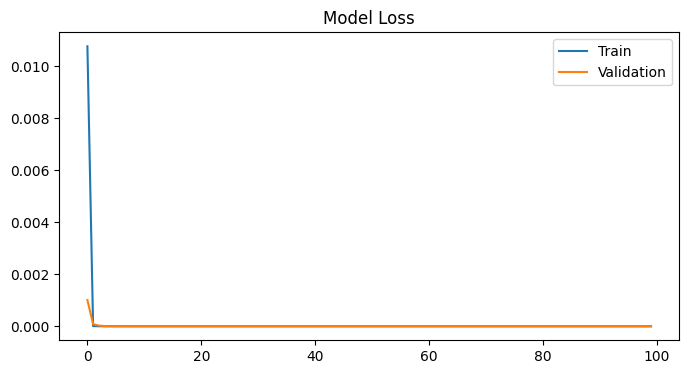

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.legend(['Train','Validation'])

plt.show()

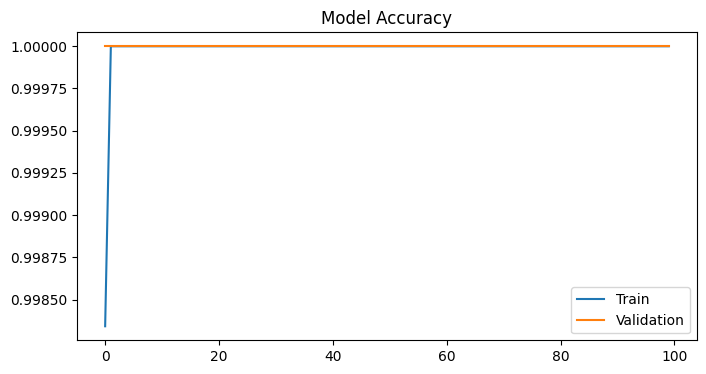

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.legend(['Train','Validation'])

plt.show()

# Conclusion

The Cervical Cancer Prediction System was successfully developed using machine learning and deep learning techniques to predict biopsy outcomes based on patient demographic, behavioral, and medical characteristics. Various preprocessing techniques, including missing value handling, duplicate removal, data balancing using SMOTE, outlier treatment, and feature scaling, were applied to improve data quality and model performance. Multiple classification algorithms such as Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, SVM, XGBoost, and a Deep Learning model were trained and evaluated.

The experimental results demonstrated exceptional predictive performance, with all models achieving an accuracy of 100% on the processed dataset. These findings indicate that the selected features are highly effective in distinguishing between positive and negative biopsy outcomes. The developed system can assist healthcare professionals in early cervical cancer risk assessment, enabling timely diagnosis, better treatment planning, and improved patient care. This study highlights the potential of artificial intelligence and machine learning in supporting medical decision-making and preventive healthcare.


# Future Scope

The Cervical Cancer Prediction System can be further enhanced by incorporating larger and more diverse healthcare datasets to improve its robustness and generalization capabilities. Advanced deep learning models, feature selection techniques, and explainable AI methods can be integrated to provide more accurate and interpretable predictions. Additionally, the system can be connected with electronic health record (EHR) systems and deployed as a real-time clinical decision support tool, enabling healthcare professionals to identify high-risk patients more efficiently and support early diagnosis and preventive care.